# Post 08: How Do Equilibrium Samples Become Free Energies?

This notebook is the presentation layer for the eighth tutorial. The reusable PMF, reweighting, synthetic RDF-PMF, compact argon RDF-PMF, and figure logic lives in `src/kups_md_tutorials/`.


In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.figures import generate_post08_figures
from kups_md_tutorials.free_energies import load_free_energy_summary

## Configuration

The smoke and full profiles sample a known double-well equilibrium distribution and compare histogram PMFs, bootstrap uncertainty, reweighting, a synthetic RDF-derived PMF with an answer key, and a compact reduced-unit argon trajectory RDF-derived PMF with block and replica uncertainty diagnostics.

In [3]:
for profile in ["smoke", "full"]:
    print(f"--- {profile} ---")
    print(json.dumps(json.loads(Path(f"configs/post-08/{profile}.json").read_text()), indent=2))

--- smoke ---
{
  "post": "08",
  "profile": "smoke",
  "title": "How Do Equilibrium Samples Become Free Energies?",
  "free_energy_experiment": {
    "temperature": 1.0,
    "sample_count": 12000,
    "seed": 2026071408,
    "domain_min": -2.5,
    "domain_max": 2.5,
    "grid_points": 801,
    "bin_widths": [
      0.1,
      0.25
    ],
    "bootstrap_replicates": 80,
    "bias_center": 0.9,
    "bias_strength": 2.0,
    "rdf_peak_radius": 1.2,
    "rdf_peak_width": 0.16
  },
  "argon_rdf_pmf": {
    "repetitions": 2,
    "number_density": 0.85,
    "temperature": 0.7,
    "gamma": 1.0,
    "time_step": 0.002,
    "num_steps": 3000,
    "warmup_steps": 500,
    "sample_every": 20,
    "seed": 2026071808,
    "rdf_max_radius": 3.0,
    "rdf_bin_width": 0.04,
    "coordination_cutoff": 1.45,
    "max_vacf_lag": 50,
    "epsilon": 1.0,
    "sigma": 1.0,
    "cutoff": 2.5,
    "uncertainty_block_count": 4,
    "uncertainty_replica_count": 3,
    "target_device": "cpu"
  }
}
--- full ---

## Committed Results

The summary reports barrier estimates for each bin width, bootstrap standard errors, a reweighted barrier, synthetic RDF-PMF diagnostics, and compact argon trajectory RDF-PMF diagnostics.

In [4]:
summary = load_free_energy_summary(Path("results/post-08/full/free_energy_summary.json"))
print("true barrier=", round(summary.true_barrier_height, 4))
for item in summary.bins:
    print("bin", item.bin_width, "barrier=", round(item.barrier_height, 4), "+/-", round(item.bootstrap_barrier_standard_error, 4), "rmse=", round(item.rmse_vs_true, 4))
print("reweighted barrier=", round(summary.reweighted_barrier_height, 4))
if summary.argon_rdf_pmf is not None:
    argon = summary.argon_rdf_pmf
    print(
        "argon RDF-PMF minimum=",
        round(argon.pmf_minimum_radius, 4),
        "range=",
        round(argon.pmf_barrier_height, 4),
        "finite bins=",
        argon.finite_pmf_bins,
    )
    print(
        "argon RDF-PMF uncertainty: blocks=",
        argon.uncertainty_block_count,
        "replicas=",
        argon.uncertainty_replica_count,
        "max block SEM=",
        round(argon.max_block_pmf_sem, 4),
        "max replica std=",
        round(argon.max_replica_pmf_std, 4),
    )
    print(
        "argon runtime provenance: target=",
        argon.target_device,
        "runtime=",
        argon.runtime_device,
        "production GPU ready=",
        argon.production_gpu_ready,
    )
    print("argon GPU blocking reason=", argon.gpu_blocking_reason)
    print(
        "argon support thresholds=",
        list(argon.support_thresholds),
        "finite bins=",
        list(argon.support_threshold_finite_bins),
    )
    print(
        "argon support PMF ranges=",
        [round(value, 4) for value in argon.support_threshold_pmf_ranges],
        "range span=",
        round(argon.support_threshold_range_span, 4),
    )


true barrier= 1.0
bin 0.06 barrier= 0.9854 +/- 0.032 rmse= 0.1707
bin 0.18 barrier= 0.9761 +/- 0.0166 rmse= 0.3665
bin 0.35 barrier= 0.9152 +/- 0.0174 rmse= 0.5906
reweighted barrier= 1.1229
argon RDF-PMF minimum= 1.125 range= 1.6429 finite bins= 52
argon RDF-PMF uncertainty: blocks= 4 replicas= 3 max block SEM= 0.029 max replica std= 0.0616
argon runtime provenance: target= cuda_or_cpu_fallback runtime= jax:cpu;devices:cpu production GPU ready= False
argon GPU blocking reason= target device requests CUDA/GPU, but generated artifact runtime was jax:cpu;devices:cpu
argon support thresholds= [0.02, 0.05, 0.1] finite bins= [53, 52, 52]
argon support PMF ranges= [2.9979, 1.6429, 1.6429] range span= 1.355


## Figure

The full-profile figure is regenerated from committed compact outputs, including the compact argon RDF-to-PMF panel with block SEM and replica-disagreement overlays.

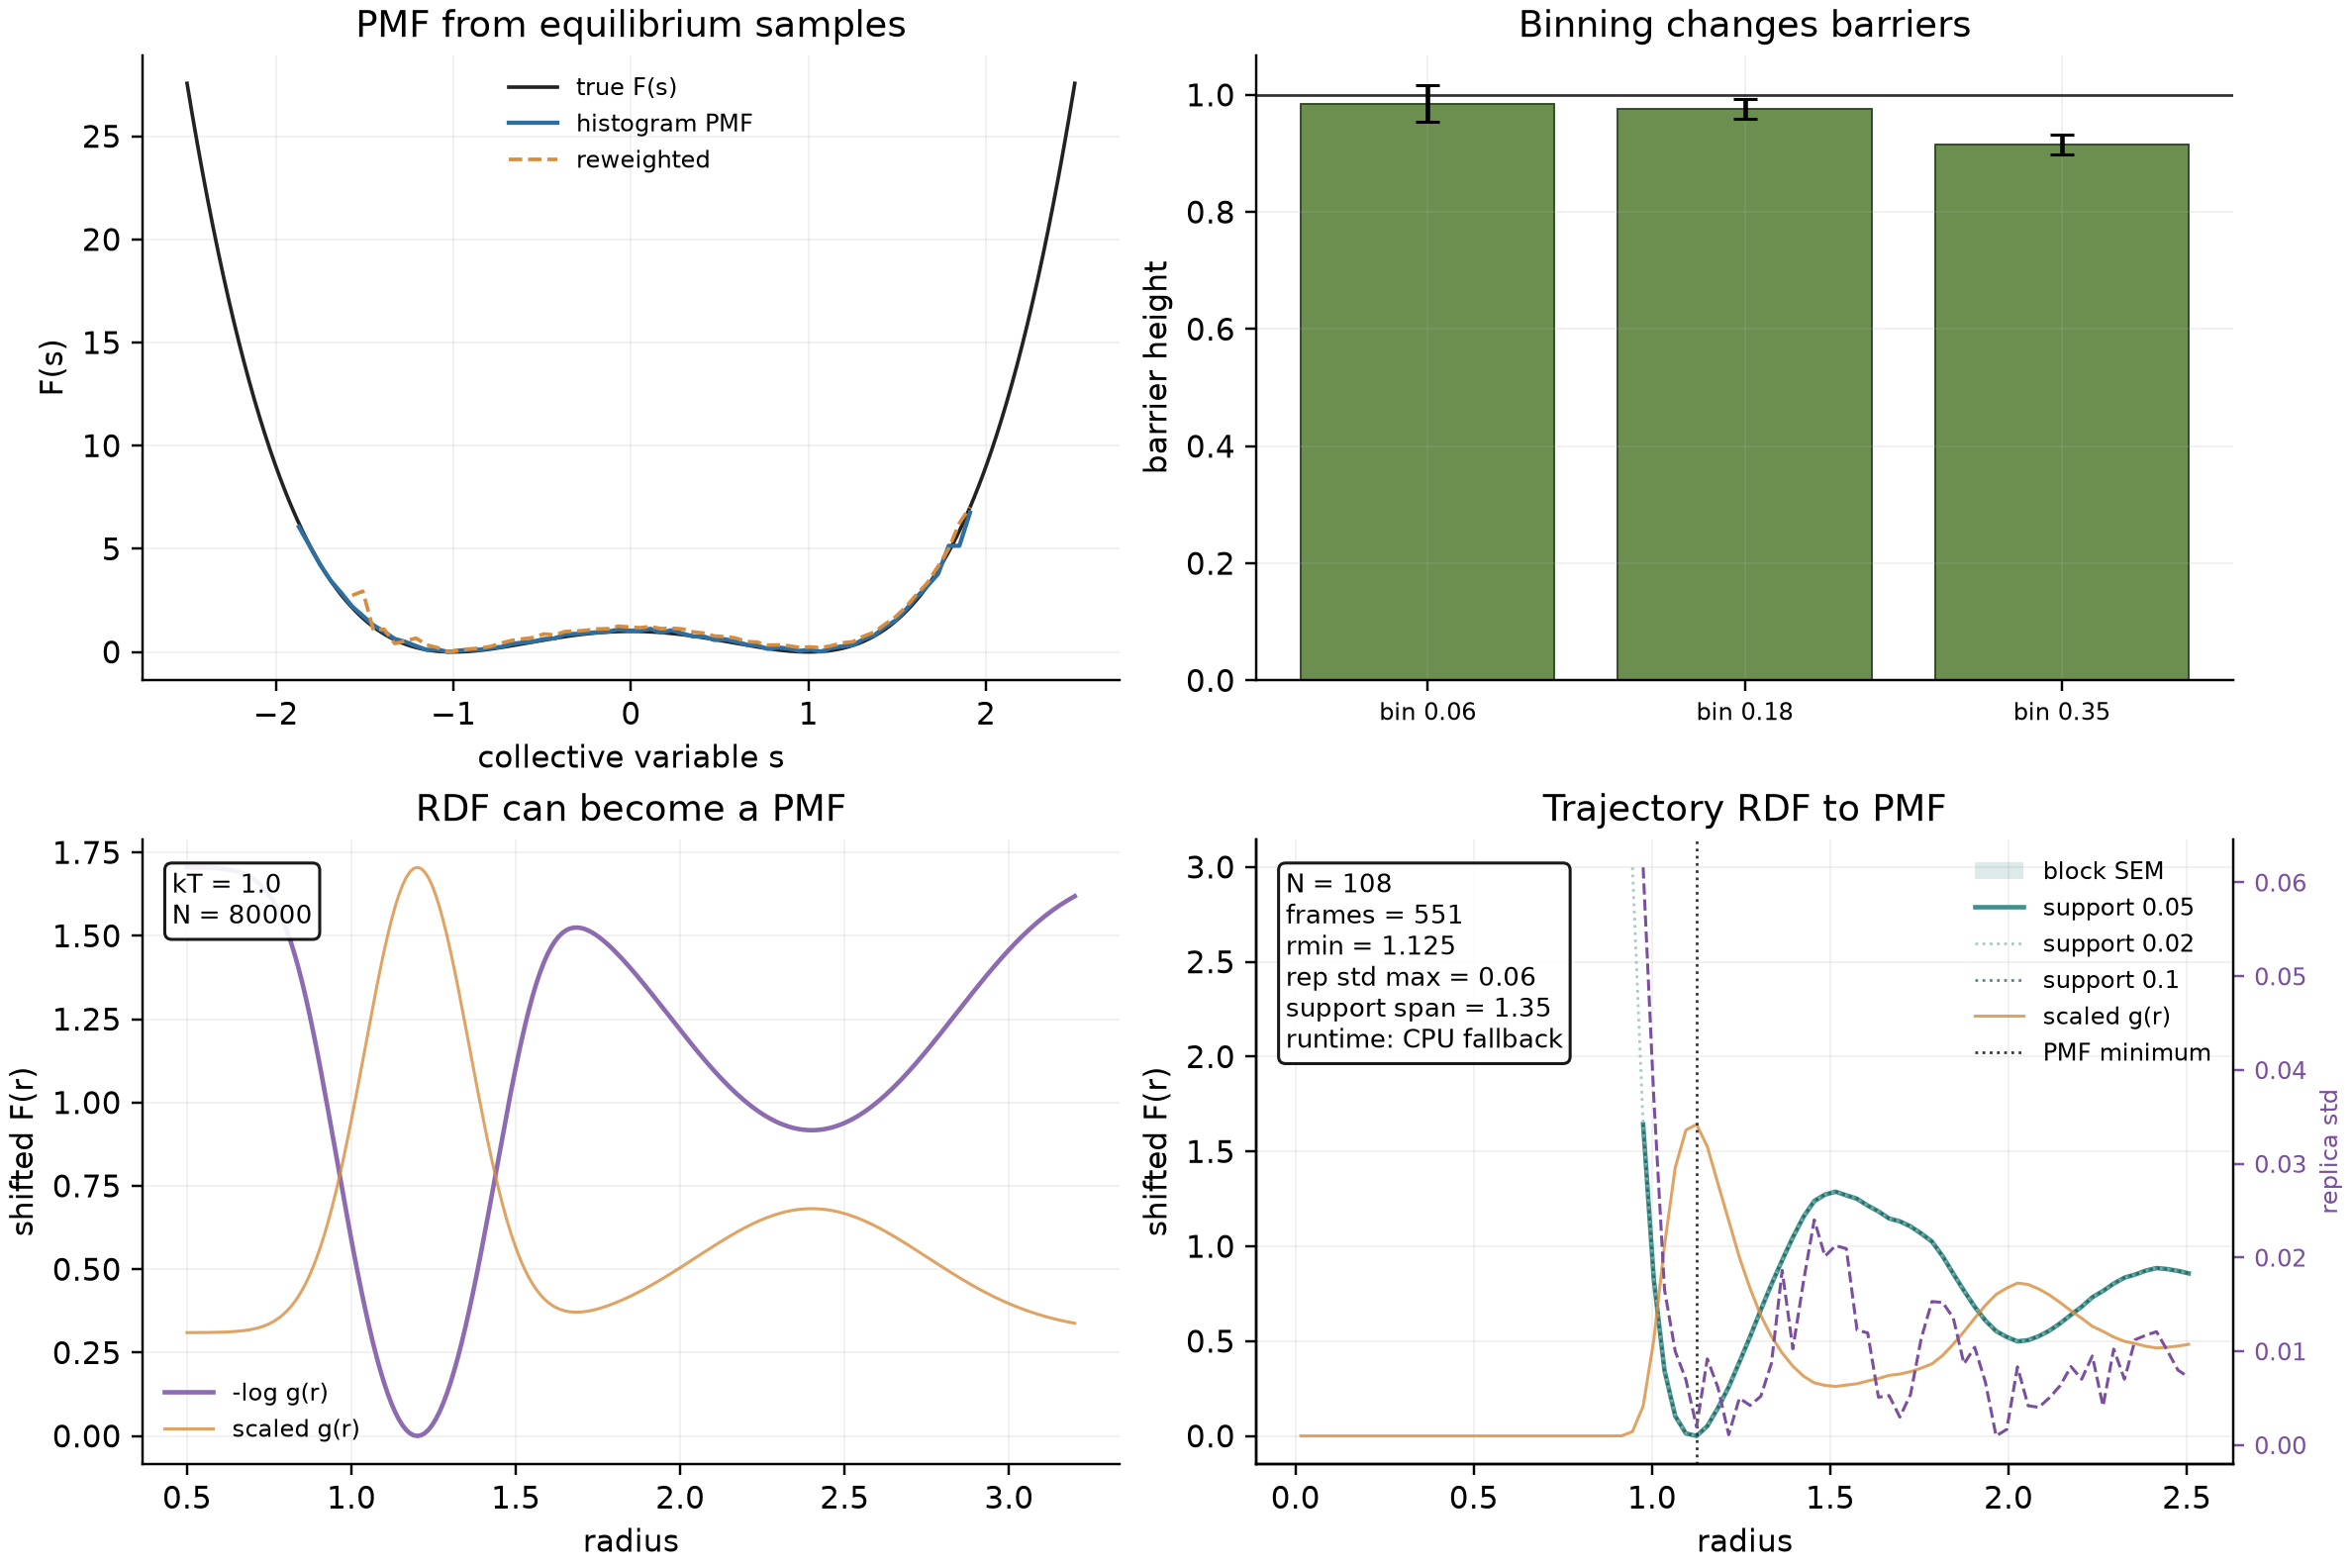

In [5]:
generate_post08_figures(
    result_dir=Path("results/post-08/full"),
    figure_dir=Path("figures/post-08"),
    snapshot_dir=Path("snapshots/post-08"),
    name="free_energy_diagnostics_full",
)
display(Image(filename="figures/post-08/free_energy_diagnostics_full.png"))